# FTPrimitiveBench — visualization

Render and save the patch + spacetime-timeline figures into the surrounding `figures/` directory. Run cell-by-cell.

- `plot_patch` — matplotlib 2D rendering of a surface-code patch.
- `plot_*_timeline` — interactive plotly 3D rendering of a primitive's spacetime evolution.

All 3D figures share the same default camera view (`x=0.8, y=-2.4, z=0.4`) so they're directly comparable. Plotly figures save as both interactive HTML and static PNG (PNG requires `kaleido`).

## Setup

Imports plus a small `save_figure(fig, name)` helper that handles both matplotlib and plotly figures, applies the default 3D camera, and falls back to HTML if `kaleido` is missing.

In [10]:
from pathlib import Path

from ft_primitive_bench.surface_code.circuits import rectangular_surface_code_patch
from ft_primitive_bench.surface_code.visualization import (
    plot_patch,
    plot_memory_timeline,
    plot_transversal_h_timeline,
    plot_lattice_surgery_timeline,
    plot_s_gate_timeline,
)

FIGURES_DIR = Path.cwd()
DEFAULT_CAMERA_EYE = dict(x=0.8, y=-2.4, z=0.4)


def save_figure(fig, name, *, png=False, plotly_size=(900, 700), scale=2, dpi=180):
    """Save a matplotlib or plotly figure into FIGURES_DIR.

    Matplotlib figures save as PNG via ``fig.savefig`` (cheap).

    Plotly figures save as interactive HTML by default — fast (~tens of ms)
    and what you want while iterating. Static PNG export goes through
    ``kaleido``, which spawns a headless Chromium and re-renders the 3D
    scene; that's slow (1-10 s per figure) and only worth doing when you
    need a paper-ready snapshot. Pass ``png=True`` to also write the PNG.

    The default 3D camera (``DEFAULT_CAMERA_EYE``) is applied to every
    scene before rendering so HTML and PNG snapshots agree across primitives.
    """
    out = FIGURES_DIR / name
    # Matplotlib branch: plain savefig (fast).
    if hasattr(fig, "savefig") and not hasattr(fig, "write_image"):
        out = out.with_suffix(".png")
        fig.savefig(out, dpi=dpi, bbox_inches="tight")
        return out
    # Plotly branch.
    fig.update_scenes(camera_eye=DEFAULT_CAMERA_EYE)
    html_path = out.with_suffix(".html")
    fig.write_html(html_path, include_plotlyjs="cdn")
    if not png:
        return html_path
    png_path = out.with_suffix(".png")
    try:
        fig.write_image(png_path, width=plotly_size[0], height=plotly_size[1], scale=scale)
        return png_path
    except (ValueError, ImportError) as exc:
        print(f"kaleido missing ({exc}); kept {html_path.name} only")
        return html_path

## 2D patches

Filled stabilizer plaquettes (red = X, blue = Z). Data qubits are white-filled circles, ancillas are basis-colored — the marker convention matches the 3D timeline plots below.

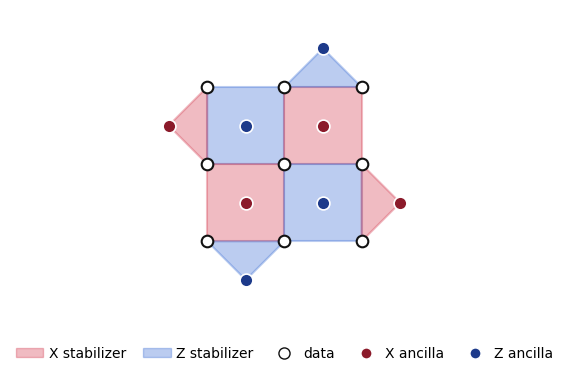

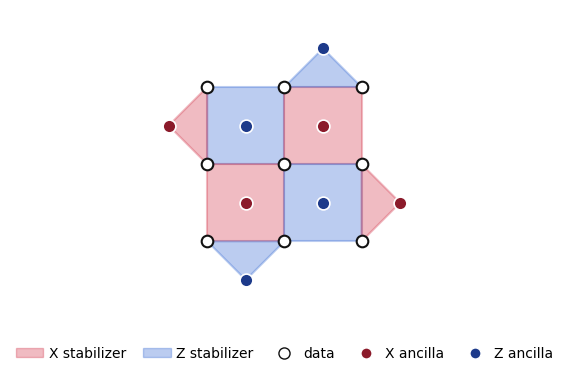

In [11]:
patch = rectangular_surface_code_patch(x_distance=3, z_distance=3)
fig, ax = plot_patch(patch, figsize=(5, 5), legend=True, show=False)
# save_figure(fig, "patch_3x3")
fig

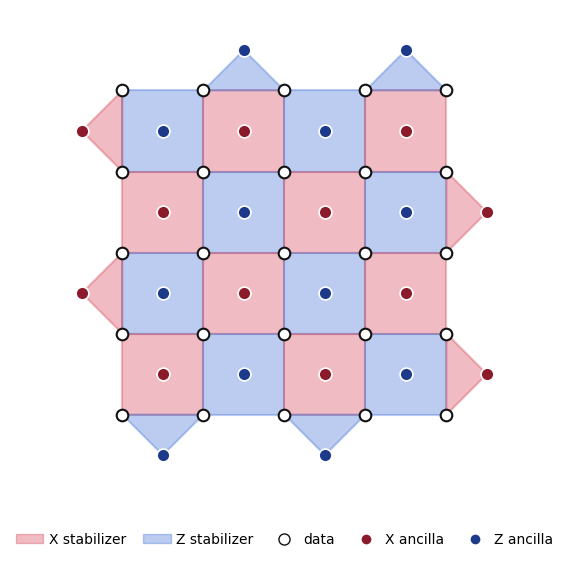

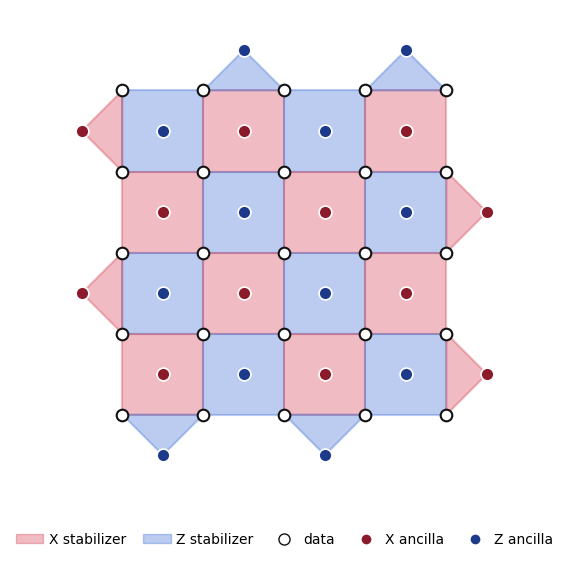

In [12]:
patch = rectangular_surface_code_patch(x_distance=5, z_distance=5)
fig, ax = plot_patch(patch, figsize=(6, 6), legend=True, show=False)
# save_figure(fig, "patch_5x5")
fig

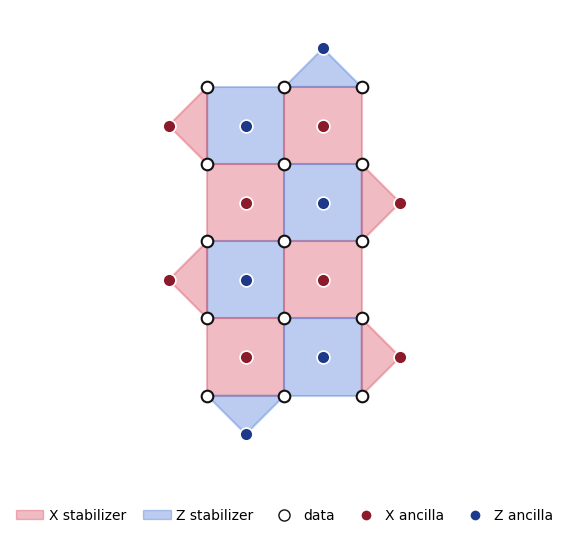

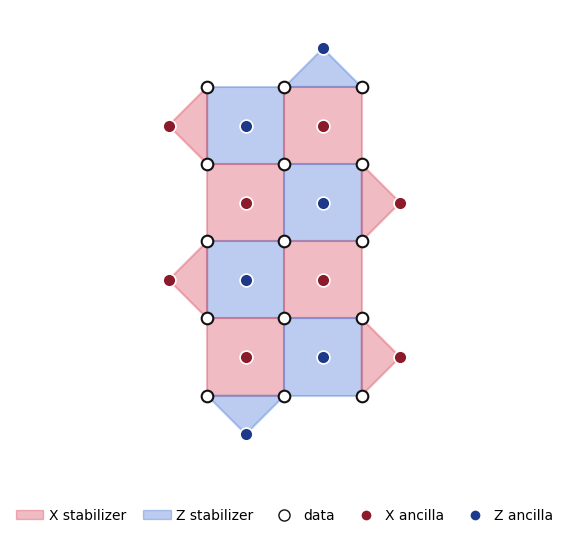

In [19]:
patch = rectangular_surface_code_patch(x_distance=3, z_distance=5)
fig, ax = plot_patch(patch, figsize=(5, 7), legend=True, show=False)
# save_figure(fig, "patch_3x5")
fig

## 3D spacetime timelines

Each `plot_*_timeline(...)` takes the same arguments as its matching primitive builder and returns an interactive plotly figure. Stabilizer rounds stack along the time axis; gate operations are colored per type.

Calling `save_figure(fig, "name")` writes only the interactive HTML — fast (tens of ms). Pass `png=True` to also write a static PNG via `kaleido`; that's slow (1-10 s per figure) and intended for paper-ready exports.

In [ ]:
mem_fig = plot_memory_timeline(
    x_distance=3, z_distance=3, rounds=3, meas_basis="Z", show=False,
)
#  save_figure(mem_fig, "memory_timeline")
mem_fig

In [16]:
h_fig = plot_transversal_h_timeline(
    x_distance=3, z_distance=3, pre_rounds=2, post_rounds=2, meas_basis="Z", show=False,
)
# save_figure(h_fig, "transversal_h_timeline")
h_fig

In [17]:
ls_fig = plot_lattice_surgery_timeline(
    x_distance=3, z_distance=3, bridge_length=1,
    pre_rounds=2, merge_rounds=3, post_rounds=2,
    horizontal=True, meas_basis="Z", show=False,
)
# save_figure(ls_fig, "lattice_surgery_timeline")
ls_fig

In [18]:
s_fig = plot_s_gate_timeline(
    distance=3, bridge_length=1,
    pre_rounds=0, merge_rounds=3, boundary_rounds=2,
    horizontal=False, show=False,
)
# save_figure(s_fig, "s_gate_timeline")
s_fig